In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv(r'anime.csv')

In [4]:
def extract_episodes(txt):
    check = False
    data = ""
    for i in txt:
        if i == ')':
            check == False
            return data
        if check ==True:
            data += i 
        if i == '(':
            check = True

In [5]:
df["Episodes"] = df['Title'].apply(extract_episodes)

In [6]:
df["Episodes"] = df["Episodes"].str.replace(' eps', '')

In [7]:
df["Episodes"] = df["Episodes"].astype(int)

In [8]:
df

,Rank,Title,Score,Episodes
0,1,Fullmetal Alchemist: BrotherhoodTV (64 eps)Apr...,9.10,64
1,2,"Steins;GateTV (24 eps)Apr 2011 - Sep 20112,473...",9.07,24
2,3,Bleach: Sennen Kessen-henTV (13 eps)Oct 2022 -...,9.06,13
3,4,"Gintama°TV (51 eps)Apr 2015 - Mar 2016605,113 ...",9.06,51
4,5,Shingeki no Kyojin Season 3 Part 2TV (10 eps)A...,9.05,10
5,6,"Gintama'TV (51 eps)Apr 2011 - Mar 2012534,105 ...",9.04,51
6,7,Gintama: The FinalMovie (1 eps)Jan 2021 - Jan ...,9.04,1
7,8,Hunter x Hunter TV (148 eps)Oct 2011 - Sep 201...,9.04,148
8,9,Kaguya-sama wa Kokurasetai: Ultra RomanticTV (...,9.04,13
9,10,Gintama': EnchousenTV (13 eps)Oct 2012 - Mar 2...,9.03,13


In [9]:
def StartDate(txt):
    check = False
    data = ""
    for i in range(len(txt)):
        if txt[i] == ')':
            for j in range(i+1,i+10):
                data += txt[j]
            return data

In [10]:
df['Start Date'] = df['Title'].apply(StartDate)

In [11]:
def EndDate(txt):
    check = False
    data = ""
    for i in range(len(txt)):
        if txt[i] == ')':
            for j in range(i+11,i+20):
                data += txt[j]
            return data

In [12]:
df['End Date'] = df['Title'].apply(EndDate)

In [13]:
df['Start Date'] = df['Start Date'].str.strip()
df['End Date'] = df['End Date'].str.strip()

In [14]:
df['Start Date'] = pd.to_datetime(df['Start Date'], format='%b %Y')
df['End Date'] = pd.to_datetime(df['End Date'], format='%b %Y')

In [15]:
df['Total Months'] = (
    (df['End Date'].dt.year - df['Start Date'].dt.year) * 12
    + (df['End Date'].dt.month - df['Start Date'].dt.month)
    + 1
)

In [16]:
df

,Rank,Title,Score,Episodes,Start Date,End Date,Total Months
0,1,Fullmetal Alchemist: BrotherhoodTV (64 eps)Apr...,9.10,64,2009-04-01,2010-07-01,16
1,2,"Steins;GateTV (24 eps)Apr 2011 - Sep 20112,473...",9.07,24,2011-04-01,2011-09-01,6
2,3,Bleach: Sennen Kessen-henTV (13 eps)Oct 2022 -...,9.06,13,2022-10-01,2022-12-01,3
3,4,"Gintama°TV (51 eps)Apr 2015 - Mar 2016605,113 ...",9.06,51,2015-04-01,2016-03-01,12
4,5,Shingeki no Kyojin Season 3 Part 2TV (10 eps)A...,9.05,10,2019-04-01,2019-07-01,4
5,6,"Gintama'TV (51 eps)Apr 2011 - Mar 2012534,105 ...",9.04,51,2011-04-01,2012-03-01,12
6,7,Gintama: The FinalMovie (1 eps)Jan 2021 - Jan ...,9.04,1,2021-01-01,2021-01-01,1
7,8,Hunter x Hunter TV (148 eps)Oct 2011 - Sep 201...,9.04,148,2011-10-01,2014-09-01,36
8,9,Kaguya-sama wa Kokurasetai: Ultra RomanticTV (...,9.04,13,2022-04-01,2022-06-01,3
9,10,Gintama': EnchousenTV (13 eps)Oct 2012 - Mar 2...,9.03,13,2012-10-01,2013-03-01,6


In [38]:
def clean_Title(txt):
    data = ""
    for i in txt:
        if i == '(':
            return data.strip()
        data += i
    return data.strip()


    

In [39]:
df["Clean Title"] = df['Title'].apply(clean_Title)

In [40]:
df

,Rank,Title,Score,Episodes,Start Date,End Date,Total Months,Clean Title
0,1,Fullmetal Alchemist: BrotherhoodTV (64 eps)Apr...,9.10,64,2009-04-01,2010-07-01,16,Fullmetal Alchemist: BrotherhoodTV
1,2,"Steins;GateTV (24 eps)Apr 2011 - Sep 20112,473...",9.07,24,2011-04-01,2011-09-01,6,Steins;GateTV
2,3,Bleach: Sennen Kessen-henTV (13 eps)Oct 2022 -...,9.06,13,2022-10-01,2022-12-01,3,Bleach: Sennen Kessen-henTV
3,4,"Gintama°TV (51 eps)Apr 2015 - Mar 2016605,113 ...",9.06,51,2015-04-01,2016-03-01,12,Gintama°TV
4,5,Shingeki no Kyojin Season 3 Part 2TV (10 eps)A...,9.05,10,2019-04-01,2019-07-01,4,Shingeki no Kyojin Season 3 Part 2TV
5,6,"Gintama'TV (51 eps)Apr 2011 - Mar 2012534,105 ...",9.04,51,2011-04-01,2012-03-01,12,Gintama'TV
6,7,Gintama: The FinalMovie (1 eps)Jan 2021 - Jan ...,9.04,1,2021-01-01,2021-01-01,1,Gintama: The FinalMovie
7,8,Hunter x Hunter TV (148 eps)Oct 2011 - Sep 201...,9.04,148,2011-10-01,2014-09-01,36,Hunter x Hunter TV
8,9,Kaguya-sama wa Kokurasetai: Ultra RomanticTV (...,9.04,13,2022-04-01,2022-06-01,3,Kaguya-sama wa Kokurasetai: Ultra RomanticTV
9,10,Gintama': EnchousenTV (13 eps)Oct 2012 - Mar 2...,9.03,13,2012-10-01,2013-03-01,6,Gintama': EnchousenTV


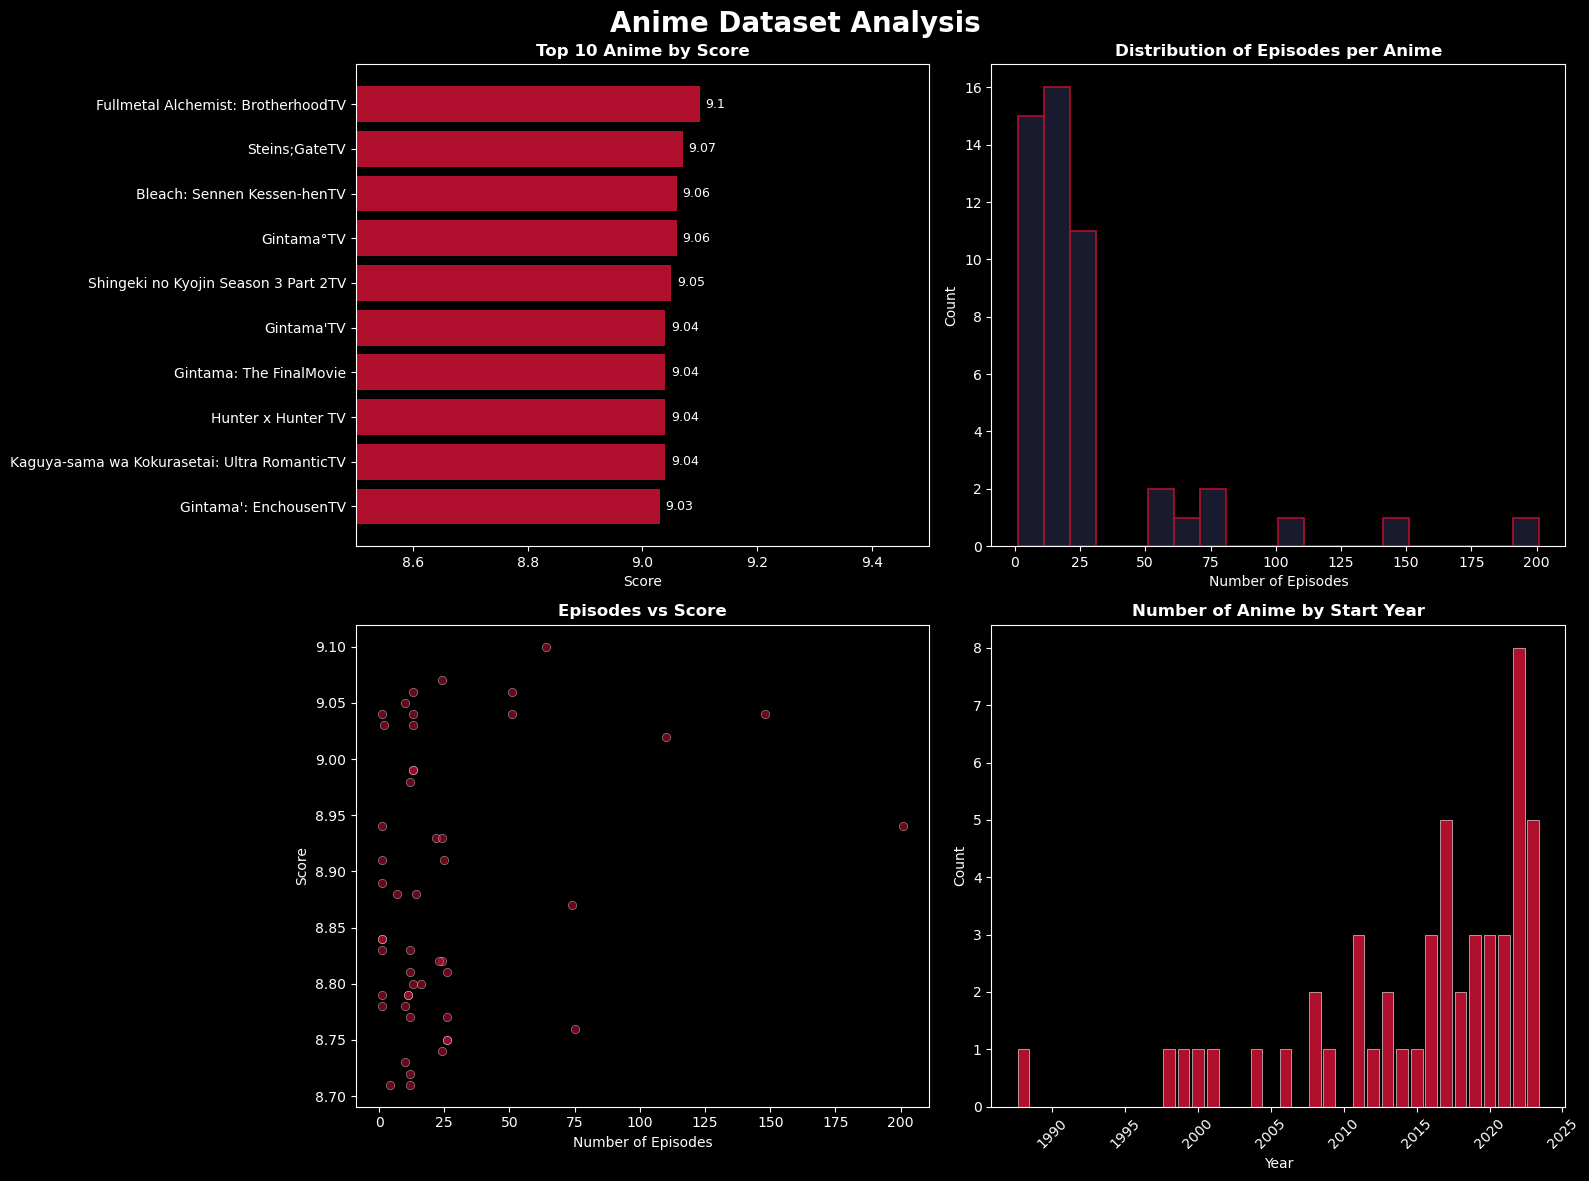

In [65]:
plt.style.use('dark_background')
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Anime Dataset Analysis', fontsize=20, fontweight='bold', color='white')

# --- Chart 1: Top 10 Anime by Score ---
top10 = df.nlargest(10, 'Score')
axes[0, 0].barh(top10['Clean Title'], top10['Score'], color='#B10F2E')
axes[0, 0].set_title('Top 10 Anime by Score', fontweight='bold')
axes[0, 0].set_xlabel('Score')
axes[0, 0].invert_yaxis()
axes[0, 0].set_xlim(8.5, 9.5)
for i, (val, name) in enumerate(zip(top10['Score'], top10['Clean Title'])):
    axes[0, 0].text(val + 0.01, i, f'{val}', va='center', fontsize=9)

# --- Chart 2: Episodes Distribution ---
axes[0, 1].hist(df['Episodes'], bins=20, color='#1A1A2E', edgecolor='#B10F2E', linewidth=1.2)
axes[0, 1].set_title('Distribution of Episodes per Anime', fontweight='bold')
axes[0, 1].set_xlabel('Number of Episodes')
axes[0, 1].set_ylabel('Count')

# --- Chart 3: Score vs Episodes Scatter ---
axes[1, 0].scatter(df['Episodes'], df['Score'], color='#B10F2E', alpha=0.6, edgecolors='white', linewidth=0.4)
axes[1, 0].set_title('Episodes vs Score', fontweight='bold')
axes[1, 0].set_xlabel('Number of Episodes')
axes[1, 0].set_ylabel('Score')

# --- Chart 4: Anime Count by Start Year ---
df['Start Year'] = df['Start Date'].dt.year
year_counts = df['Start Year'].value_counts().sort_index()
axes[1, 1].bar(year_counts.index, year_counts.values, color='#B10F2E', edgecolor='white', linewidth=0.4)
axes[1, 1].set_title('Number of Anime by Start Year', fontweight='bold')
axes[1, 1].set_xlabel('Year')
axes[1, 1].set_ylabel('Count')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('anime_analysis.png', dpi=150, bbox_inches='tight')
plt.show()